In [ ]:
# ============================================================
# USING GEE, GET:
#
# 1. Dynamic World top class
# 2. Dynamic World top class probability
# 3. Dynamic World built probability
# 4. AlphaEarth mean value for 64 bands
# 5. Google Open Buildings 2.5D maximum building confidence
#
# THEN:
#
# Join all GEE results back to the original GeoPackage
# using:
#     new_id
#
# OUTPUT:
#     - CSV with GEE attributes
#     - GeoPackage layer with original geometry/attributes
#       + GEE information
#
# Google 2.5D:
#     Year = 2023
#     Resolution = 4 meters
#     Statistic = MAXIMUM within each building
# ============================================================


import ee
import pandas as pd
import geopandas as gpd
import time
import os


# ============================================================
# SETTINGS
# ============================================================

iso = "LSO"


# ------------------------------------------------------------
# Input building GeoPackage
# ------------------------------------------------------------

# Input building footprints
BUILDINGS = rf"E:\buildings\{city}\outputs\{city}_overture_buildings_cleaned.gpkg"
layer = f"{city}_overture_buildings_cleaned"





# ------------------------------------------------------------
# Output CSV
# ------------------------------------------------------------

OUTPUT_CSV = (
    rf"E:\buildings\{city}\outputs"
    rf"\{city}_buildings_alpha_dynamic_25d.csv"
)


# ------------------------------------------------------------
# Output GeoPackage
# ------------------------------------------------------------

OUTPUT_GPKG = (
    rf"E:\buildings\{city}\data"
    rf"\{city}_overture_buildings_gee.gpkg"
)


# ------------------------------------------------------------
# Output GeoPackage layer
# ------------------------------------------------------------

OUTPUT_LAYER = (
    f"{city}_overture_buildings_gee"
)


# ------------------------------------------------------------
# Dynamic World / AlphaEarth year
# ------------------------------------------------------------

YEAR = 2025


# ------------------------------------------------------------
# Google Open Buildings 2.5D year
# ------------------------------------------------------------

GOOGLE_25D_YEAR = 2023


# ------------------------------------------------------------
# Earth Engine resolution
# ------------------------------------------------------------

SCALE = 10


# ------------------------------------------------------------
# Google 2.5D resolution
# ------------------------------------------------------------

GOOGLE_25D_SCALE = 4


# ------------------------------------------------------------
# Batch size
# ------------------------------------------------------------

BATCH_SIZE = 5000


# ------------------------------------------------------------
# Pause between requests
# ------------------------------------------------------------

PAUSE_SECONDS = 0.5


# ------------------------------------------------------------
# Building ID
# ------------------------------------------------------------

ID_FIELD = "new_id"


# ============================================================
# DYNAMIC WORLD CLASS INFORMATION
# ============================================================

DW_CLASSES = [
    "water",
    "trees",
    "grass",
    "flooded_vegetation",
    "crops",
    "shrub_and_scrub",
    "built",
    "bare",
    "snow_and_ice"
]


DW_CLASS_NAMES = {
    0: "Water",
    1: "Trees",
    2: "Grass",
    3: "Flooded vegetation",
    4: "Crops",
    5: "Shrub and scrub",
    6: "Built",
    7: "Bare",
    8: "Snow and ice"
}


# ============================================================
# INITIALIZE EARTH ENGINE
# ============================================================

print("Authenticating Earth Engine...")

ee.Authenticate()

ee.Initialize()


# ============================================================
# READ BUILDINGS
# ============================================================

print("\nReading buildings...")

gdf_original = gpd.read_file(
    BUILDINGS,
    layer=layer
)

print(
    f"Original buildings: "
    f"{len(gdf_original)}"
)


# ============================================================
# CREATE NEW ID FIELD
# ============================================================

print(
    f"\nChecking ID field: {ID_FIELD}"
)


if ID_FIELD not in gdf_original.columns:

    print(
        f"{ID_FIELD} not found. "
        "Creating sequential IDs..."
    )

    gdf_original[ID_FIELD] = range(
        1,
        len(gdf_original) + 1
    )

else:

    print(
        f"{ID_FIELD} already exists. "
        "Using existing values."
    )


# ============================================================
# CHECK ID
# ============================================================

print(
    f"\nChecking {ID_FIELD}..."
)

print(
    f"Unique IDs: "
    f"{gdf_original[ID_FIELD].nunique()}"
)

print(
    f"Missing IDs: "
    f"{gdf_original[ID_FIELD].isna().sum()}"
)


# ============================================================
# SAVE ORIGINAL GDF FOR FINAL JOIN
# ============================================================

gdf_output = gdf_original.copy()


# ============================================================
# CREATE PROCESSING COPY
# ============================================================

gdf = gdf_original[
    [ID_FIELD, "geometry"]
].copy()


# ============================================================
# REMOVE EMPTY GEOMETRIES
# ============================================================

empty_count = (
    gdf.geometry.isna().sum()
)


if empty_count > 0:

    print(
        f"\nRemoving "
        f"{empty_count} empty geometries "
        "from GEE processing..."
    )

    gdf = gdf[
        ~gdf.geometry.isna()
    ].copy()


# ============================================================
# REMOVE INVALID GEOMETRIES
# ============================================================

invalid_count = (
    (~gdf.geometry.is_valid).sum()
)


if invalid_count > 0:

    print(
        f"\nFixing "
        f"{invalid_count} invalid geometries..."
    )

    gdf["geometry"] = (
        gdf.geometry.make_valid()
    )


# ============================================================
# REPROJECT PROCESSING COPY
# ============================================================

print(
    "\nReprojecting processing layer "
    "to EPSG:4326..."
)

gdf = gdf.to_crs(
    "EPSG:4326"
)


print(
    f"Buildings ready for GEE: "
    f"{len(gdf)}"
)


# ============================================================
# LOAD DYNAMIC WORLD
# ============================================================

print(
    "\nLoading Dynamic World..."
)


dynamic_world = (
    ee.ImageCollection(
        "GOOGLE/DYNAMICWORLD/V1"
    )
    .filterDate(
        f"{YEAR}-01-01",
        f"{YEAR + 1}-01-01"
    )
)


dw_count = (
    dynamic_world
    .size()
    .getInfo()
)


print(
    f"Dynamic World images found: "
    f"{dw_count}"
)


# ============================================================
# ANNUAL MEAN DYNAMIC WORLD
# ============================================================

print(
    "\nCalculating annual mean "
    "Dynamic World probabilities..."
)


dw_probability_image = (
    dynamic_world
    .select(DW_CLASSES)
    .mean()
)


print(
    "Dynamic World probability bands:"
)


print(
    dw_probability_image
    .bandNames()
    .getInfo()
)


# ============================================================
# LOAD ALPHAEARTH
# ============================================================

print(
    "\nLoading AlphaEarth embeddings..."
)


alphaearth = (
    ee.ImageCollection(
        "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
    )
    .filterDate(
        f"{YEAR}-01-01",
        f"{YEAR + 1}-01-01"
    )
)


alpha_count = (
    alphaearth
    .size()
    .getInfo()
)


print(
    f"AlphaEarth images found: "
    f"{alpha_count}"
)


# ============================================================
# CREATE ALPHAEARTH MOSAIC
# ============================================================

print(
    "\nCreating AlphaEarth mosaic..."
)


embedding = (
    alphaearth
    .mosaic()
)


# ============================================================
# GET ALPHAEARTH BAND NAMES
# ============================================================

alpha_band_names = (
    embedding
    .bandNames()
    .getInfo()
)


print(
    "\nNumber of AlphaEarth dimensions:"
)

print(
    len(alpha_band_names)
)


print(
    "\nAlphaEarth bands:"
)

print(
    alpha_band_names
)


# ============================================================
# CHECK 64 BANDS
# ============================================================

if len(alpha_band_names) != 64:

    print(
        "\nWARNING:"
    )

    print(
        f"Expected 64 AlphaEarth bands, "
        f"but found {len(alpha_band_names)}."
    )

else:

    print(
        "\nConfirmed: 64 AlphaEarth bands."
    )


# ============================================================
# LOAD GOOGLE OPEN BUILDINGS 2.5D
# ============================================================

print(
    "\nLoading Google Open Buildings 2.5D..."
)


google_25d = (
    ee.ImageCollection(
        "GOOGLE/Research/open-buildings-temporal/v1"
    )
    .filterDate(
        f"{GOOGLE_25D_YEAR}-01-01",
        f"{GOOGLE_25D_YEAR + 1}-01-01"
    )
)


google_25d_count = (
    google_25d
    .size()
    .getInfo()
)


print(
    f"Google 2.5D images found for "
    f"{GOOGLE_25D_YEAR}: "
    f"{google_25d_count}"
)


# ============================================================
# GET GOOGLE 2.5D TIMESTAMPS
# ============================================================

if google_25d_count > 0:

    print(
        "\nGoogle 2.5D image dates:"
    )

    dates = (
        google_25d
        .aggregate_array(
            "system:time_start"
        )
        .getInfo()
    )

    for timestamp in dates:

        if timestamp is not None:

            date = pd.to_datetime(
                timestamp,
                unit="ms"
            )

            print(
                f"  {date.date()}"
            )


# ============================================================
# CREATE GOOGLE 2.5D IMAGE
# ============================================================

print(
    "\nCreating Google 2.5D 2023 image..."
)


# If multiple observations exist in 2023,
# take the temporal maximum first.
#
# This produces the highest building_presence
# observed at each pixel during 2023.

google_25d_image = (
    google_25d
    .select(
        "building_presence"
    )
    .max()
)


print(
    "Google 2.5D band:"
)

print(
    google_25d_image
    .bandNames()
    .getInfo()
)


# ============================================================
# PROCESS BUILDINGS IN BATCHES
# ============================================================

total_buildings = len(gdf)


total_batches = (
    total_buildings
    + BATCH_SIZE
    - 1
) // BATCH_SIZE


print(
    "\n=========================================="
)

print(
    "STARTING BATCH PROCESSING"
)

print(
    "=========================================="
)


print(
    f"Total buildings: "
    f"{total_buildings}"
)


print(
    f"Batch size: "
    f"{BATCH_SIZE}"
)


print(
    f"Number of batches: "
    f"{total_batches}"
)


all_records = []


# ============================================================
# BATCH LOOP
# ============================================================

for start in range(
    0,
    total_buildings,
    BATCH_SIZE
):

    end = min(
        start + BATCH_SIZE,
        total_buildings
    )


    batch_number = (
        start // BATCH_SIZE
    ) + 1


    print(
        f"\nBatch "
        f"{batch_number}/{total_batches} "
        f"({start + 1}-{end})"
    )


    # --------------------------------------------------------
    # GET BATCH
    # --------------------------------------------------------

    batch_gdf = (
        gdf.iloc[
            start:end
        ].copy()
    )


    # --------------------------------------------------------
    # CONVERT TO EARTH ENGINE
    # --------------------------------------------------------

    print(
        "  Converting buildings "
        "to Earth Engine..."
    )


    geojson = (
        batch_gdf[
            [ID_FIELD, "geometry"]
        ].__geo_interface__
    )


    buildings_ee = (
        ee.FeatureCollection(
            geojson
        )
    )


    # ========================================================
    # DYNAMIC WORLD + ALPHAEARTH
    # ========================================================

    try:

        print(
            "  Calculating "
            "Dynamic World + AlphaEarth..."
        )


        combined_image = (
            dw_probability_image
            .addBands(
                embedding
            )
        )


        results = (
            combined_image
            .reduceRegions(

                collection=buildings_ee,

                reducer=ee.Reducer.mean(),

                scale=SCALE,

                tileScale=4

            )
        )


        print(
            "  Downloading "
            "Dynamic World + AlphaEarth..."
        )


        data = (
            results
            .getInfo()
        )


        batch_records = []


        for feature in data["features"]:

            properties = (
                feature["properties"]
            )

            batch_records.append(
                properties
            )


        print(
            f"  DW/AlphaEarth records: "
            f"{len(batch_records)}"
        )


    except Exception as e:

        print(
            f"\nERROR processing "
            f"DW/AlphaEarth in batch "
            f"{batch_number}:"
        )

        print(e)

        batch_records = []


    # ========================================================
    # GOOGLE 2.5D MAXIMUM
    # ========================================================

    try:

        print(
            "  Calculating Google 2.5D "
            "MAXIMUM within buildings "
            f"at {GOOGLE_25D_SCALE} m..."
        )


        google_results = (
            google_25d_image
            .reduceRegions(

                collection=buildings_ee,

                # IMPORTANT:
                # Maximum pixel value within
                # each building.
                reducer=ee.Reducer.max(),

                scale=GOOGLE_25D_SCALE,

                tileScale=4

            )
        )


        print(
            "  Downloading Google 2.5D results..."
        )


        google_data = (
            google_results
            .getInfo()
        )


        google_records = []


        for feature in google_data["features"]:

            properties = (
                feature["properties"]
            )

            google_records.append(
                properties
            )


        print(
            f"  Google 2.5D records: "
            f"{len(google_records)}"
        )


    except Exception as e:

        print(
            f"\nERROR processing "
            f"Google 2.5D in batch "
            f"{batch_number}:"
        )

        print(e)

        google_records = []


    # ========================================================
    # MERGE BATCH RESULTS BY new_id
    # ========================================================

    batch_df = pd.DataFrame(
        batch_records
    )


    google_df = pd.DataFrame(
        google_records
    )


    if len(batch_df) > 0:

        batch_df[ID_FIELD] = (
            pd.to_numeric(
                batch_df[ID_FIELD],
                errors="coerce"
            )
        )


    if len(google_df) > 0:

        google_df[ID_FIELD] = (
            pd.to_numeric(
                google_df[ID_FIELD],
                errors="coerce"
            )
        )


        # Find the actual Google value column.
        google_value_columns = [
            c
            for c in google_df.columns
            if c != ID_FIELD
        ]


        if len(google_value_columns) > 0:

            google_value_column = (
                google_value_columns[0]
            )


            google_df = google_df[
                [
                    ID_FIELD,
                    google_value_column
                ]
            ].rename(
                columns={
                    google_value_column:
                        "google25d_max_confidence"
                }
            )


            if len(batch_df) > 0:

                batch_df = batch_df.merge(
                    google_df,
                    on=ID_FIELD,
                    how="left"
                )

            else:

                batch_df = google_df


    all_records.append(
        batch_df
    )


    current_count = sum(
        len(x)
        for x in all_records
        if isinstance(x, pd.DataFrame)
    )


    print(
        f"  Total records accumulated: "
        f"{current_count} / "
        f"{total_buildings}"
    )


    time.sleep(
        PAUSE_SECONDS
    )


# ============================================================
# COMBINE ALL GEE RESULTS
# ============================================================

print(
    "\nCombining all GEE results..."
)


valid_records = [
    x
    for x in all_records
    if isinstance(x, pd.DataFrame)
    and len(x) > 0
]


if len(valid_records) == 0:

    raise RuntimeError(
        "No buildings were returned "
        "from Earth Engine."
    )


df = pd.concat(
    valid_records,
    ignore_index=True
)


# ============================================================
# REMOVE DUPLICATE IDs
# ============================================================

print(
    f"\nGEE records before "
    f"duplicate removal: {len(df)}"
)


df = df.drop_duplicates(
    subset=[ID_FIELD],
    keep="first"
).copy()


print(
    f"GEE records after "
    f"duplicate removal: {len(df)}"
)


# ============================================================
# DETERMINE TOP DYNAMIC WORLD CLASS
# ============================================================

print(
    "\nDetermining top Dynamic World class..."
)


# ------------------------------------------------------------
# Make sure all DW columns exist
# ------------------------------------------------------------

for class_name in DW_CLASSES:

    if class_name not in df.columns:

        print(
            f"WARNING: "
            f"{class_name} not found."
        )

        df[class_name] = pd.NA


# ------------------------------------------------------------
# Convert DW values to numeric
# ------------------------------------------------------------

dw_values = (
    df[
        DW_CLASSES
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


# ------------------------------------------------------------
# Top class
# ------------------------------------------------------------

df["dw_top_class"] = (
    dw_values
    .idxmax(
        axis=1
    )
)


# ============================================================
# TOP DYNAMIC WORLD PROBABILITY
# ============================================================

df["dw_top_probability"] = (
    dw_values
    .max(
        axis=1
    )
)


# ============================================================
# CLASS ID
# ============================================================

class_to_id = {
    name: i
    for i, name
    in enumerate(DW_CLASSES)
}


df["dw_top_class_id"] = (
    df["dw_top_class"]
    .map(class_to_id)
)


# ============================================================
# HUMAN-READABLE CLASS
# ============================================================

df["dw_top_class_name"] = (
    df["dw_top_class_id"]
    .map(DW_CLASS_NAMES)
)


# ============================================================
# BUILT PROBABILITY
# ============================================================

df["dw_built_probability"] = (
    pd.to_numeric(
        df["built"],
        errors="coerce"
    )
)


# ============================================================
# RENAME ALPHAEARTH COLUMNS
# ============================================================

print(
    "\nRenaming AlphaEarth columns..."
)


rename_dict = {}


for band in alpha_band_names:

    rename_dict[band] = (
        f"alphaearth_{band}"
    )


df = df.rename(
    columns=rename_dict
)


# ============================================================
# ALPHAEARTH COLUMN LIST
# ============================================================

alpha_columns = [

    f"alphaearth_{band}"

    for band in alpha_band_names

    if f"alphaearth_{band}"
    in df.columns

]


print(
    f"AlphaEarth columns retrieved: "
    f"{len(alpha_columns)}"
)


# ============================================================
# ENSURE GOOGLE 2.5D COLUMN EXISTS
# ============================================================

if (
    "google25d_max_confidence"
    not in df.columns
):

    print(
        "WARNING: Google 2.5D "
        "results not found."
    )

    df[
        "google25d_max_confidence"
    ] = pd.NA


else:

    df[
        "google25d_max_confidence"
    ] = pd.to_numeric(
        df[
            "google25d_max_confidence"
        ],
        errors="coerce"
    )


# ============================================================
# REMOVE RAW DYNAMIC WORLD COLUMNS
# ============================================================

print(
    "\nRemoving raw Dynamic World "
    "probability columns..."
)


df = df.drop(
    columns=[
        c
        for c in DW_CLASSES
        if c in df.columns
    ],
    errors="ignore"
)


# ============================================================
# REORDER GEE DATAFRAME
# ============================================================

preferred_columns = [

    ID_FIELD,

    "dw_top_class_id",

    "dw_top_class",

    "dw_top_class_name",

    "dw_top_probability",

    "dw_built_probability",

    "google25d_max_confidence"

]


preferred_columns = [
    c
    for c in preferred_columns
    if c in df.columns
]


other_columns = [

    c
    for c in df.columns

    if c not in preferred_columns

    and c not in alpha_columns

]


ordered_columns = (

    preferred_columns
    + alpha_columns
    + other_columns

)


df = df[
    [
        c
        for c in ordered_columns
        if c in df.columns
    ]
]


# ============================================================
# MAKE ID TYPES MATCH BEFORE JOIN
# ============================================================

print(
    "\nPreparing ID fields for join..."
)


gdf_output[ID_FIELD] = pd.to_numeric(
    gdf_output[ID_FIELD],
    errors="coerce"
)


df[ID_FIELD] = pd.to_numeric(
    df[ID_FIELD],
    errors="coerce"
)


# ============================================================
# CHECK FOR DUPLICATE IDs IN ORIGINAL LAYER
# ============================================================

duplicate_ids = (
    gdf_output[ID_FIELD]
    .duplicated()
    .sum()
)


if duplicate_ids > 0:

    print(
        f"WARNING: "
        f"{duplicate_ids} duplicate "
        f"{ID_FIELD} values in original layer."
    )


# ============================================================
# JOIN GEE RESULTS TO ORIGINAL GEOPACKAGE
# ============================================================

print(
    "\n=========================================="
)

print(
    "JOINING GEE RESULTS TO GEOPACKAGE"
)

print(
    "=========================================="
)


print(
    f"Original features: "
    f"{len(gdf_output)}"
)


print(
    f"GEE records: "
    f"{len(df)}"
)


# ------------------------------------------------------------
# Prevent geometry or index fields from entering join
# ------------------------------------------------------------

gee_join = df.copy()


gee_join = gee_join.drop(
    columns=[
        "geometry"
    ],
    errors="ignore"
)


# ------------------------------------------------------------
# Avoid duplicate non-ID fields
#
# Since the original layer may already contain
# fields with these names, remove those fields
# from the original before joining.
# ------------------------------------------------------------

gee_fields = [
    c
    for c in gee_join.columns
    if c != ID_FIELD
]


existing_conflicts = [
    c
    for c in gee_fields
    if c in gdf_output.columns
]


if len(existing_conflicts) > 0:

    print(
        "\nExisting fields that will be "
        "replaced by GEE results:"
    )

    print(
        existing_conflicts
    )

    gdf_output = gdf_output.drop(
        columns=existing_conflicts
    )


# ------------------------------------------------------------
# JOIN
# ------------------------------------------------------------

gdf_output = gdf_output.merge(
    gee_join,
    on=ID_FIELD,
    how="left",
    validate="one_to_one"
)


# ============================================================
# CHECK JOIN
# ============================================================

print(
    "\nJoin complete."
)


print(
    f"Output features: "
    f"{len(gdf_output)}"
)


# ------------------------------------------------------------
# Determine buildings with GEE data
# ------------------------------------------------------------

gee_match_count = (
    gdf_output[
        "dw_top_class_name"
    ]
    .notna()
    .sum()
)


print(
    f"Buildings with GEE results: "
    f"{gee_match_count}"
)


print(
    f"Buildings without GEE results: "
    f"{len(gdf_output) - gee_match_count}"
)


# ============================================================
# SAVE CSV
# ============================================================

print(
    "\nSaving CSV..."
)


output_dir = (
    os.path.dirname(
        OUTPUT_CSV
    )
)


if output_dir:

    os.makedirs(
        output_dir,
        exist_ok=True
    )


df.to_csv(
    OUTPUT_CSV,
    index=False
)


print(
    f"CSV saved:"
)

print(
    OUTPUT_CSV
)


# ============================================================
# SAVE GEOPACKAGE
# ============================================================

print(
    "\nSaving GeoPackage..."
)


gpkg_dir = (
    os.path.dirname(
        OUTPUT_GPKG
    )
)


if gpkg_dir:

    os.makedirs(
        gpkg_dir,
        exist_ok=True
    )


# ------------------------------------------------------------
# If the output GeoPackage already exists,
# remove the existing layer so that the script
# can be rerun.
# ------------------------------------------------------------

if os.path.exists(
    OUTPUT_GPKG
):

    import fiona

    existing_layers = (
        fiona.listlayers(
            OUTPUT_GPKG
        )
    )

    if OUTPUT_LAYER in existing_layers:

        print(
            f"Removing existing layer: "
            f"{OUTPUT_LAYER}"
        )

        # GeoPandas/Fiona cannot overwrite
        # a single existing layer reliably in
        # all environments, so use driver mode
        # with layer replacement below.
        #
        # We delete the entire GPKG if it only
        # contains the requested output layer.

        if len(existing_layers) == 1:

            os.remove(
                OUTPUT_GPKG
            )

        else:

            # Keep other layers and overwrite
            # the requested layer.
            pass


# ------------------------------------------------------------
# Write output GeoPackage
# ------------------------------------------------------------

gdf_output.to_file(
    OUTPUT_GPKG,
    layer=OUTPUT_LAYER,
    driver="GPKG",
    index=False
)


print(
    "\nGeoPackage saved:"
)

print(
    OUTPUT_GPKG
)


print(
    "\nGeoPackage layer:"
)

print(
    OUTPUT_LAYER
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\n=========================================="
)

print(
    "COMPLETE"
)

print(
    "=========================================="
)


print(
    f"Original buildings: "
    f"{len(gdf_original)}"
)


print(
    f"GEE records: "
    f"{len(df)}"
)


print(
    f"Final GeoPackage features: "
    f"{len(gdf_output)}"
)


print(
    f"Buildings with GEE results: "
    f"{gee_match_count}"
)


print(
    f"Missing GEE results: "
    f"{len(gdf_output) - gee_match_count}"
)


print(
    f"AlphaEarth dimensions: "
    f"{len(alpha_columns)}"
)


print(
    "Dynamic World year: "
    f"{YEAR}"
)


print(
    "Google 2.5D year: "
    f"{GOOGLE_25D_YEAR}"
)


print(
    "Google 2.5D resolution: "
    f"{GOOGLE_25D_SCALE} m"
)


print(
    f"\nCSV:"
)

print(
    OUTPUT_CSV
)


print(
    f"\nGeoPackage:"
)

print(
    OUTPUT_GPKG
)


print(
    f"\nGeoPackage layer:"
)

print(
    OUTPUT_LAYER
)


# ============================================================
# DYNAMIC WORLD SUMMARY
# ============================================================

print(
    "\nDynamic World top-class counts:"
)


print(
    df[
        "dw_top_class_name"
    ].value_counts(
        dropna=False
    )
)


# ============================================================
# GOOGLE 2.5D SUMMARY
# ============================================================

print(
    "\nGoogle 2.5D maximum confidence summary:"
)


print(
    gdf_output[
        "google25d_max_confidence"
    ].describe()
)


# ============================================================
# ALPHAEARTH SUMMARY
# ============================================================

print(
    "\nAlphaEarth columns:"
)


print(
    len(alpha_columns)
)


# ============================================================
# ID SUMMARY
# ============================================================

print(
    "\nID summary:"
)


print(
    f"Unique {ID_FIELD}: "
    f"{gdf_output[ID_FIELD].nunique()}"
)


print(
    f"Missing {ID_FIELD}: "
    f"{gdf_output[ID_FIELD].isna().sum()}"
)


# ============================================================
# FINAL FIELD LIST
# ============================================================

print(
    "\nFinal GeoPackage fields:"
)


for field in gdf_output.columns:

    print(
        f"  {field}"
    )


# ============================================================
# FIRST FEW ROWS
# ============================================================

print(
    "\nFirst few rows:"
)


print(
    gdf_output.head()
)

In [ ]:
# ============================================================
# ISOLATION FOREST + t-SNE
#
# INPUT:
#   {city}_overture_buildings_gee.gpkg
#
# AlphaEarth:
#   64 alphaearth_ columns
#
# Uses:
#   new_id
#
# Existing GEE information retained:
#   - dw_top_class_id
#   - dw_top_class
#   - dw_top_class_name
#   - dw_top_probability
#   - dw_built_probability
#   - google25d_max_confidence
#   - source_provider
#   - source_year
#   - all other original attributes
#
# OUTPUT:
#   - CSV
#   - GeoPackage
#   - t-SNE by Dynamic World class
#   - t-SNE by Isolation Forest status
# ============================================================


import os

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.manifold import TSNE


# ============================================================
# SETTINGS
# ============================================================

# ------------------------------------------------------------
# City
# ------------------------------------------------------------

city = "Kigali"


# ------------------------------------------------------------
# Input GeoPackage with buildings containing gee information on google 2.5d, alphaearth, and dynamic world
# ------------------------------------------------------------

INPUT_GPKG = (
    rf"E:\buildings\{city}\data"
    rf"\{city}_overture_buildings_gee.gpkg"
)


# ------------------------------------------------------------
# Input layer
#
# This should match the layer created by the previous script.
# ------------------------------------------------------------

INPUT_LAYER = (
    f"{city}_overture_buildings_gee"
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

OUTPUT_FOLDER = (
    rf"E:\buildings\{city}\outputs"
    rf"\outlier_results_isolation_forest"
)

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)


# ------------------------------------------------------------
# Output GeoPackage
# ------------------------------------------------------------

OUTPUT_GPKG = (
    rf"{OUTPUT_FOLDER}"
    rf"\{city}_buildings_isolation_forest_tsne.gpkg"
)


# ------------------------------------------------------------
# Output GeoPackage layer
# ------------------------------------------------------------

OUTPUT_LAYER = (
    f"{city}_buildings_if_tsne"
)


# ------------------------------------------------------------
# Output CSV
# ------------------------------------------------------------

OUTPUT_CSV = (
    rf"{OUTPUT_FOLDER}"
    rf"\{city}_buildings_isolation_forest_tsne.csv"
)


# ------------------------------------------------------------
# Building ID
# ------------------------------------------------------------

ID_FIELD = "new_id"


# ------------------------------------------------------------
# AlphaEarth
# ------------------------------------------------------------

EXPECTED_ALPHA_BANDS = 64


# ------------------------------------------------------------
# Isolation Forest
# ------------------------------------------------------------

IF_CONTAMINATION = 0.05

IF_N_ESTIMATORS = 300


# ------------------------------------------------------------
# t-SNE
# ------------------------------------------------------------

TSNE_PERPLEXITY = 30


# ------------------------------------------------------------
# General
# ------------------------------------------------------------

RANDOM_STATE = 42


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

PLOT_SIZE = (8, 6)

LINEWIDTH = 0


# ============================================================
# FIND ALPHAEARTH COLUMNS
# ============================================================

def find_alphaearth_columns(df):

    alpha_columns = [

        col

        for col in df.columns

        if str(col)
        .lower()
        .startswith(
            "alphaearth_"
        )

    ]

    # --------------------------------------------------------
    # Sort by band name
    # --------------------------------------------------------

    alpha_columns = sorted(
        alpha_columns,
        key=lambda x: str(x)
    )

    return alpha_columns


# ============================================================
# LOAD GEOPACKAGE
# ============================================================

def load_city_data():

    print("\n" + "=" * 70)

    print(
        "LOADING GEE GEOPACKAGE"
    )

    print("=" * 70)


    print(
        f"Input GeoPackage:\n"
        f"{INPUT_GPKG}"
    )


    print(
        f"Input layer:\n"
        f"{INPUT_LAYER}"
    )


    # --------------------------------------------------------
    # Check GeoPackage
    # --------------------------------------------------------

    if not os.path.exists(
        INPUT_GPKG
    ):

        raise FileNotFoundError(
            f"GeoPackage not found:\n"
            f"{INPUT_GPKG}"
        )


    # --------------------------------------------------------
    # Read GeoPackage
    # --------------------------------------------------------

    gdf = gpd.read_file(
        INPUT_GPKG,
        layer=INPUT_LAYER
    )


    print(
        f"\nBuildings loaded: "
        f"{len(gdf):,}"
    )


    # --------------------------------------------------------
    # Check ID
    # --------------------------------------------------------

    if ID_FIELD not in gdf.columns:

        raise KeyError(
            f"{ID_FIELD} not found "
            "in GeoPackage."
        )


    print(
        f"Unique {ID_FIELD}: "
        f"{gdf[ID_FIELD].nunique():,}"
    )


    print(
        f"Missing {ID_FIELD}: "
        f"{gdf[ID_FIELD].isna().sum():,}"
    )


    # --------------------------------------------------------
    # Show existing fields
    # --------------------------------------------------------

    print(
        "\nFields in GeoPackage:"
    )


    for field in gdf.columns:

        print(
            f"  {field}"
        )


    return gdf.reset_index(
        drop=True
    )


# ============================================================
# PREPARE ALPHAEARTH FEATURES
# ============================================================

def prepare_alphaearth(gdf):

    print("\n" + "-" * 70)

    print(
        "PREPARING ALPHAEARTH FEATURES"
    )

    print("-" * 70)


    # --------------------------------------------------------
    # Find AlphaEarth columns
    # --------------------------------------------------------

    alpha_columns = (
        find_alphaearth_columns(
            gdf
        )
    )


    print(
        f"AlphaEarth columns found: "
        f"{len(alpha_columns)}"
    )


    # --------------------------------------------------------
    # Check bands
    # --------------------------------------------------------

    if len(alpha_columns) == 0:

        raise ValueError(
            "No AlphaEarth columns found. "
            "Expected columns beginning "
            "with 'alphaearth_'."
        )


    if (
        len(alpha_columns)
        != EXPECTED_ALPHA_BANDS
    ):

        print(
            f"WARNING: Expected "
            f"{EXPECTED_ALPHA_BANDS} bands "
            f"but found "
            f"{len(alpha_columns)}."
        )

    else:

        print(
            "Confirmed: 64 AlphaEarth bands."
        )


    # --------------------------------------------------------
    # Convert to numeric
    # --------------------------------------------------------

    gdf = gdf.copy()


    gdf[
        alpha_columns
    ] = (

        gdf[
            alpha_columns
        ]

        .apply(
            pd.to_numeric,
            errors="coerce"
        )

    )


    # --------------------------------------------------------
    # Check missing values
    # --------------------------------------------------------

    missing_before = (

        gdf[
            alpha_columns
        ]

        .isna()

        .any(
            axis=1
        )

        .sum()

    )


    print(
        f"Buildings with missing "
        f"AlphaEarth values: "
        f"{missing_before:,}"
    )


    # --------------------------------------------------------
    # Keep rows with complete embeddings
    #
    # NOTE:
    # This removes buildings from the analysis only.
    # The original full GeoPackage will later be restored
    # using a join on new_id.
    # --------------------------------------------------------

    analysis_gdf = (
        gdf
        .dropna(
            subset=alpha_columns
        )
        .copy()
    )


    analysis_gdf = (
        analysis_gdf
        .reset_index(
            drop=True
        )
    )


    print(
        f"Buildings retained for "
        f"Isolation Forest/t-SNE: "
        f"{len(analysis_gdf):,}"
    )


    # --------------------------------------------------------
    # Feature matrix
    # --------------------------------------------------------

    X = (
        analysis_gdf[
            alpha_columns
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    print(
        f"Final feature matrix shape: "
        f"{X.shape}"
    )


    return (
        analysis_gdf,
        X,
        alpha_columns
    )


# ============================================================
# RUN ISOLATION FOREST
# ============================================================

def run_isolation_forest(X):

    print("\n" + "-" * 70)

    print(
        "RUNNING ISOLATION FOREST"
    )

    print("-" * 70)


    # --------------------------------------------------------
    # Standardize features
    # --------------------------------------------------------

    scaler = StandardScaler()


    X_scaled = (
        scaler.fit_transform(
            X
        )
    )


    print(
        f"Scaled feature matrix: "
        f"{X_scaled.shape}"
    )


    # --------------------------------------------------------
    # Create Isolation Forest
    # --------------------------------------------------------

    iso = IsolationForest(

        contamination=
            IF_CONTAMINATION,

        n_estimators=
            IF_N_ESTIMATORS,

        random_state=
            RANDOM_STATE,

        n_jobs=-1

    )


    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    iso.fit(
        X_scaled
    )


    # --------------------------------------------------------
    # Predictions
    #
    # -1 = anomaly
    #  1 = normal
    # --------------------------------------------------------

    iso_labels = (
        iso.predict(
            X_scaled
        )
    )


    iso_outlier = (
        iso_labels == -1
    )


    # --------------------------------------------------------
    # Decision function
    #
    # Higher = more normal
    #
    # Multiply by -1:
    # Higher = more anomalous
    # --------------------------------------------------------

    iso_decision = (
        iso.decision_function(
            X_scaled
        )
    )


    iso_score = (
        -iso_decision
    )


    # --------------------------------------------------------
    # Normalize 0-1
    #
    # 0 = least anomalous
    # 1 = most anomalous
    # --------------------------------------------------------

    score_scaler = (
        MinMaxScaler()
    )


    iso_score_normalized = (

        score_scaler

        .fit_transform(
            iso_score.reshape(
                -1,
                1
            )
        )

        .ravel()

    )


    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print(
        f"Isolation Forest outliers: "
        f"{iso_outlier.sum():,}"
    )


    print(
        f"Outlier percentage: "
        f"{iso_outlier.mean() * 100:.2f}%"
    )


    return (

        X_scaled,

        iso_labels,

        iso_score,

        iso_score_normalized,

        iso_outlier

    )


# ============================================================
# CREATE t-SNE
# ============================================================

def create_tsne(
    df,
    X_scaled
):

    print("\n" + "-" * 70)

    print(
        "RUNNING t-SNE"
    )

    print("-" * 70)


    df = (
        df
        .copy()
        .reset_index(
            drop=True
        )
    )


    X_array = np.asarray(
        X_scaled,
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Validate
    # --------------------------------------------------------

    if (
        len(df)
        != X_array.shape[0]
    ):

        raise ValueError(

            f"t-SNE data mismatch: "
            f"DataFrame has "
            f"{len(df):,} rows "
            f"but X_scaled has "
            f"{X_array.shape[0]:,} rows."

        )


    n_samples = (
        X_array.shape[0]
    )


    print(
        f"Samples for t-SNE: "
        f"{n_samples:,}"
    )


    if n_samples < 6:

        raise ValueError(
            "At least 6 samples "
            "are required for t-SNE."
        )


    # --------------------------------------------------------
    # Determine valid perplexity
    # --------------------------------------------------------

    perplexity = min(

        TSNE_PERPLEXITY,

        max(
            5,
            (n_samples - 1) // 3
        )

    )


    perplexity = min(
        perplexity,
        n_samples - 1
    )


    print(
        f"t-SNE perplexity: "
        f"{perplexity}"
    )


    # --------------------------------------------------------
    # Run t-SNE
    # --------------------------------------------------------

    tsne = TSNE(

        n_components=2,

        perplexity=perplexity,

        learning_rate="auto",

        init="pca",

        random_state=RANDOM_STATE

    )


    tsne_result = (
        tsne.fit_transform(
            X_array
        )
    )


    # --------------------------------------------------------
    # Add t-SNE coordinates
    # --------------------------------------------------------

    df["TSNE1"] = (
        tsne_result[:, 0]
    )


    df["TSNE2"] = (
        tsne_result[:, 1]
    )


    print(
        "t-SNE complete."
    )


    return df


# ============================================================
# PLOT t-SNE BY DYNAMIC WORLD CLASS
# ============================================================

def plot_tsne_by_class(
    df
):

    print(
        "\nCreating t-SNE plot "
        "by Dynamic World class..."
    )


    # --------------------------------------------------------
    # Look for current GEE field
    # --------------------------------------------------------

    possible_columns = [

        "dw_top_class_name",

        "dw_top_class",

        "top_class_name",

        "top_class",

        "class_name"

    ]


    class_column = None


    for col in possible_columns:

        if col in df.columns:

            class_column = col

            break


    if class_column is None:

        print(
            "No Dynamic World class "
            "column found. "
            "Skipping class plot."
        )

        return


    plot_df = (
        df.copy()
    )


    fig, ax = plt.subplots(
        figsize=PLOT_SIZE
    )


    # --------------------------------------------------------
    # Plot classes
    # --------------------------------------------------------

    classes = sorted(

        plot_df[
            class_column
        ]

        .dropna()

        .unique()

    )


    for class_value in classes:

        mask = (

            plot_df[
                class_column
            ]

            == class_value

        ).to_numpy(
            dtype=bool
        )


        ax.scatter(

            plot_df.loc[
                mask,
                "TSNE1"
            ].to_numpy(),

            plot_df.loc[
                mask,
                "TSNE2"
            ].to_numpy(),

            s=15,

            alpha=0.6,

            label=str(
                class_value
            ),

            linewidths=LINEWIDTH

        )


    # --------------------------------------------------------
    # Highlight Isolation Forest outliers
    # --------------------------------------------------------

    outlier_mask = (

        plot_df[
            "isolation_forest_outlier"
        ]

        .to_numpy(
            dtype=bool
        )

    )


    ax.scatter(

        plot_df.loc[
            outlier_mask,
            "TSNE1"
        ].to_numpy(),

        plot_df.loc[
            outlier_mask,
            "TSNE2"
        ].to_numpy(),

        s=60,

        facecolors="none",

        edgecolors="black",

        linewidths=1,

        label="Isolation Forest Outlier"

    )


    ax.set_xlabel(
        "t-SNE 1"
    )


    ax.set_ylabel(
        "t-SNE 2"
    )


    ax.set_title(
        "AlphaEarth t-SNE by "
        "Dynamic World Class"
    )


    ax.legend(
        bbox_to_anchor=(
            1.05,
            1
        ),
        loc="upper left"
    )


    plt.tight_layout()


    output_path = os.path.join(

        OUTPUT_FOLDER,

        f"tsne_by_class_{city}.png"

    )


    plt.savefig(

        output_path,

        dpi=300,

        bbox_inches="tight"

    )


    plt.close()


    print(
        f"Saved: {output_path}"
    )


# ============================================================
# PLOT t-SNE BY ISOLATION FOREST STATUS
# ============================================================

def plot_tsne_by_anomaly(
    df
):

    print(
        "\nCreating t-SNE plot "
        "by anomaly status..."
    )


    plot_df = (
        df.copy()
    )


    normal_mask = (

        ~plot_df[
            "isolation_forest_outlier"
        ]

    ).to_numpy(
        dtype=bool
    )


    outlier_mask = (

        plot_df[
            "isolation_forest_outlier"
        ]

    ).to_numpy(
        dtype=bool
    )


    fig, ax = plt.subplots(
        figsize=PLOT_SIZE
    )


    # --------------------------------------------------------
    # Normal buildings first
    # --------------------------------------------------------

    ax.scatter(

        plot_df.loc[
            normal_mask,
            "TSNE1"
        ].to_numpy(),

        plot_df.loc[
            normal_mask,
            "TSNE2"
        ].to_numpy(),

        s=15,

        alpha=0.5,

        label="Normal",

        linewidths=LINEWIDTH

    )


    # --------------------------------------------------------
    # Outliers on top
    # --------------------------------------------------------

    ax.scatter(

        plot_df.loc[
            outlier_mask,
            "TSNE1"
        ].to_numpy(),

        plot_df.loc[
            outlier_mask,
            "TSNE2"
        ].to_numpy(),

        s=40,

        alpha=0.9,

        label="Isolation Forest Outlier",

        linewidths=LINEWIDTH

    )


    ax.set_xlabel(
        "t-SNE 1"
    )


    ax.set_ylabel(
        "t-SNE 2"
    )


    ax.set_title(
        "AlphaEarth t-SNE by "
        "Isolation Forest"
    )


    ax.legend()


    plt.tight_layout()


    output_path = os.path.join(

        OUTPUT_FOLDER,

        f"tsne_by_anomaly_{city}.png"

    )


    plt.savefig(

        output_path,

        dpi=300,

        bbox_inches="tight"

    )


    plt.close()


    print(
        f"Saved: {output_path}"
    )


# ============================================================
# JOIN RESULTS BACK TO FULL GEOPACKAGE
# ============================================================

def join_results_to_geopackage(
    original_gdf,
    analysis_df
):

    print("\n" + "-" * 70)

    print(
        "JOINING ISOLATION FOREST + t-SNE "
        "RESULTS BACK TO FULL GEOPACKAGE"
    )

    print("-" * 70)


    # --------------------------------------------------------
    # Results to join
    #
    # Keep only ID + newly calculated fields.
    # --------------------------------------------------------

    result_columns = [

        ID_FIELD,

        "isolation_forest_label",

        "isolation_forest_score",

        "isolation_forest_normalized",

        "isolation_forest_outlier",

        "TSNE1",

        "TSNE2"

    ]


    result_columns = [

        c

        for c in result_columns

        if c in analysis_df.columns

    ]


    results = (
        analysis_df[
            result_columns
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Make ID types match
    # --------------------------------------------------------

    original_gdf[ID_FIELD] = (
        pd.to_numeric(
            original_gdf[
                ID_FIELD
            ],
            errors="coerce"
        )
    )


    results[ID_FIELD] = (
        pd.to_numeric(
            results[
                ID_FIELD
            ],
            errors="coerce"
        )
    )


    # --------------------------------------------------------
    # Remove existing result fields if rerunning
    # --------------------------------------------------------

    fields_to_replace = [

        c

        for c in result_columns

        if c != ID_FIELD

        and c in original_gdf.columns

    ]


    if fields_to_replace:

        print(
            "\nReplacing existing fields:"
        )

        print(
            fields_to_replace
        )


        original_gdf = (
            original_gdf.drop(
                columns=
                    fields_to_replace
            )
        )


    # --------------------------------------------------------
    # Join
    # --------------------------------------------------------

    output_gdf = (
        original_gdf.merge(

            results,

            on=ID_FIELD,

            how="left",

            validate="one_to_one"

        )
    )


    # --------------------------------------------------------
    # Check
    # --------------------------------------------------------

    matched = (

        output_gdf[
            "isolation_forest_outlier"
        ]

        .notna()

        .sum()

    )


    print(
        f"\nOriginal buildings: "
        f"{len(original_gdf):,}"
    )


    print(
        f"Buildings with "
        f"Isolation Forest results: "
        f"{matched:,}"
    )


    print(
        f"Buildings without results: "
        f"{len(output_gdf) - matched:,}"
    )


    return output_gdf


# ============================================================
# SAVE GEOPACKAGE
# ============================================================

def save_geopackage(
    gdf
):

    print("\n" + "-" * 70)

    print(
        "SAVING OUTPUT GEOPACKAGE"
    )

    print("-" * 70)


    # --------------------------------------------------------
    # Remove existing output file
    #
    # This is safest if the GPKG is dedicated to this output.
    # --------------------------------------------------------

    if os.path.exists(
        OUTPUT_GPKG
    ):

        print(
            f"Removing existing output:"
            f"\n{OUTPUT_GPKG}"
        )

        os.remove(
            OUTPUT_GPKG
        )


    # --------------------------------------------------------
    # Write GeoPackage
    # --------------------------------------------------------

    gdf.to_file(

        OUTPUT_GPKG,

        layer=OUTPUT_LAYER,

        driver="GPKG",

        index=False

    )


    print(
        "\nGeoPackage saved:"
    )

    print(
        OUTPUT_GPKG
    )


    print(
        "\nLayer:"
    )

    print(
        OUTPUT_LAYER
    )


# ============================================================
# PROCESS
# ============================================================

def process_city():

    print("\n")

    print("#" * 70)

    print(
        f"PROCESSING: {iso.upper()}"
    )

    print("#" * 70)


    # ========================================================
    # LOAD
    # ========================================================

    original_gdf = (
        load_city_data()
    )


    # ========================================================
    # PREPARE ALPHAEARTH
    # ========================================================

    (
        analysis_gdf,
        X,
        alpha_columns
    ) = prepare_alphaearth(
        original_gdf
    )


    # ========================================================
    # ISOLATION FOREST
    # ========================================================

    (
        X_scaled,

        iso_labels,

        iso_score,

        iso_score_normalized,

        iso_outlier

    ) = run_isolation_forest(
        X
    )


    # ========================================================
    # ADD ISOLATION FOREST RESULTS
    # ========================================================

    analysis_gdf[
        "isolation_forest_label"
    ] = iso_labels


    analysis_gdf[
        "isolation_forest_score"
    ] = iso_score


    analysis_gdf[
        "isolation_forest_normalized"
    ] = iso_score_normalized


    analysis_gdf[
        "isolation_forest_outlier"
    ] = iso_outlier


    # ========================================================
    # t-SNE
    # ========================================================

    analysis_gdf = create_tsne(

        analysis_gdf,

        X_scaled

    )


    # ========================================================
    # PLOTS
    # ========================================================

    plot_tsne_by_class(
        analysis_gdf
    )


    plot_tsne_by_anomaly(
        analysis_gdf
    )


    # ========================================================
    # JOIN RESULTS TO FULL ORIGINAL GDF
    # ========================================================

    output_gdf = (
        join_results_to_geopackage(

            original_gdf,

            analysis_gdf

        )
    )


    # ========================================================
    # SAVE GEOPACKAGE
    # ========================================================

    save_geopackage(
        output_gdf
    )


    # ========================================================
    # SAVE CSV
    #
    # CSV contains the analysis records only.
    # ========================================================

    analysis_gdf.to_csv(

        OUTPUT_CSV,

        index=False

    )


    print(
        f"\nCSV saved:"
        f"\n{OUTPUT_CSV}"
    )


    # ========================================================
    # SUMMARY
    # ========================================================

    print("\n" + "=" * 70)

    print(
        f"SUMMARY: {iso.upper()}"
    )

    print("=" * 70)


    print(
        f"Original buildings: "
        f"{len(original_gdf):,}"
    )


    print(
        f"Buildings with complete "
        f"AlphaEarth embeddings: "
        f"{len(analysis_gdf):,}"
    )


    print(
        f"AlphaEarth features: "
        f"{len(alpha_columns)}"
    )


    print(
        f"Isolation Forest outliers: "
        f"{analysis_gdf['isolation_forest_outlier'].sum():,}"
    )


    print(
        f"Outlier percentage among "
        f"analyzed buildings: "
        f"{analysis_gdf['isolation_forest_outlier'].mean() * 100:.2f}%"
    )


    print(
        f"Score range: "
        f"{analysis_gdf['isolation_forest_normalized'].min():.4f} "
        f"to "
        f"{analysis_gdf['isolation_forest_normalized'].max():.4f}"
    )


    print(
        "\nFinal GeoPackage fields:"
    )


    for field in output_gdf.columns:

        print(
            f"  {field}"
        )


    print(
        "\nOutput GeoPackage:"
    )

    print(
        OUTPUT_GPKG
    )


    print(
        "\nOutput layer:"
    )

    print(
        OUTPUT_LAYER
    )


    return output_gdf


# ============================================================
# MAIN
# ============================================================

try:

    results = process_city()

except Exception as e:

    print("\n" + "!" * 70)

    print(
        f"ERROR PROCESSING {iso.upper()}"
    )

    print("!" * 70)

    print(
        e
    )

    raise


print("\n")

print("=" * 70)

print(
    "ALL PROCESSING COMPLETE"
)

print("=" * 70)

C:\Users\msw2198\AppData\Local\Temp\2\ipykernel_41680\4211758483.py:34: DtypeWarning: Columns (13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_CSV)


Loaded 154,545 buildings

Using columns:
  t-SNE 1          : TSNE1
  t-SNE 2          : TSNE2
  Dynamic World    : dw_top_class_name
  Isolation Forest : isolation_forest_outlier
  Google 2.5D      : google25d_max_confidence

Buildings with valid t-SNE coordinates: 154,545

ISOLATION FOREST OUTLIER SUMMARY
Not outlier : 146,817 (95.00%)
Outlier     : 7,728 (5.00%)

GOOGLE OPEN BUILDINGS 2.5D CONFIDENCE
Low confidence           26,920 ( 17.42%)
Medium confidence        38,900 ( 25.17%)
High confidence          84,126 ( 54.43%)
No data                   4,599 (  2.98%)

Creating Dynamic World class plot...


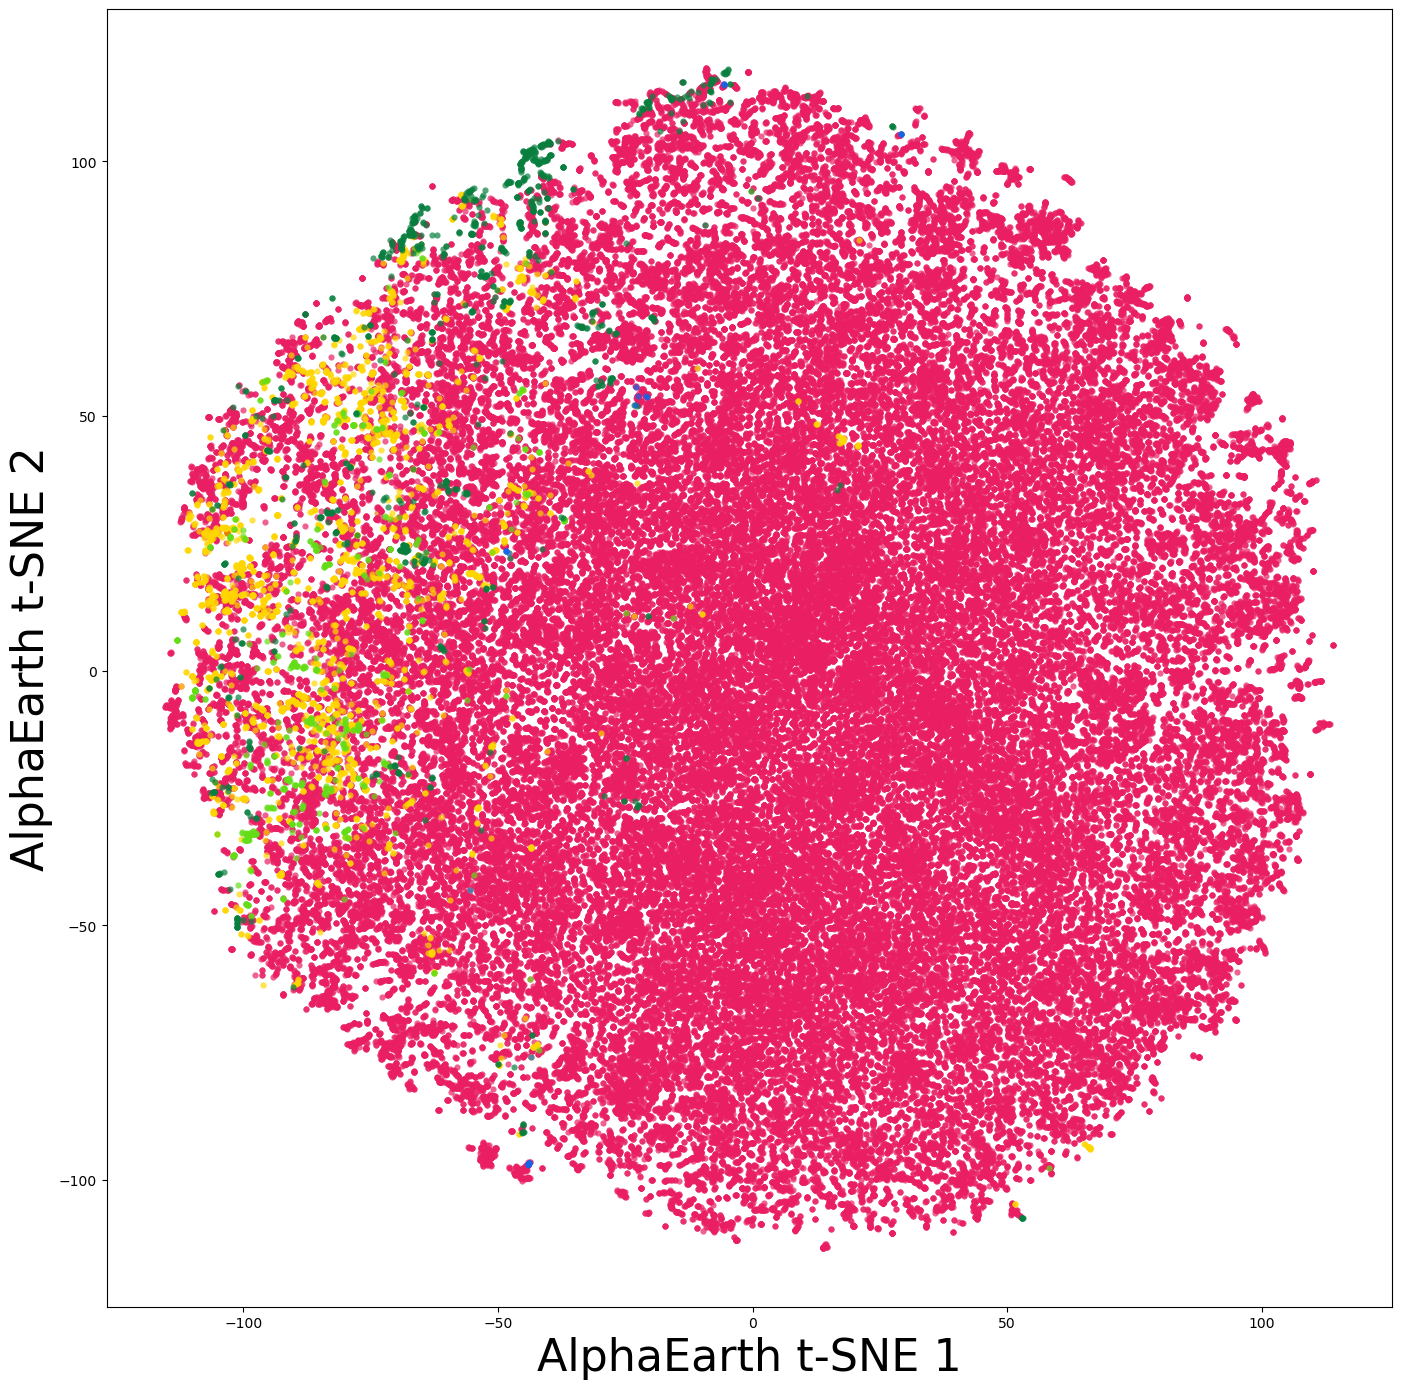


Saved class plot:
E:\buildings\LSO\outputs\outlier_results_isolation_forest\tsne_alphaearth_by_class_LSO_large.png

Creating Isolation Forest outlier plot...
  Not outlier: 146,817
  Outlier    : 7,728


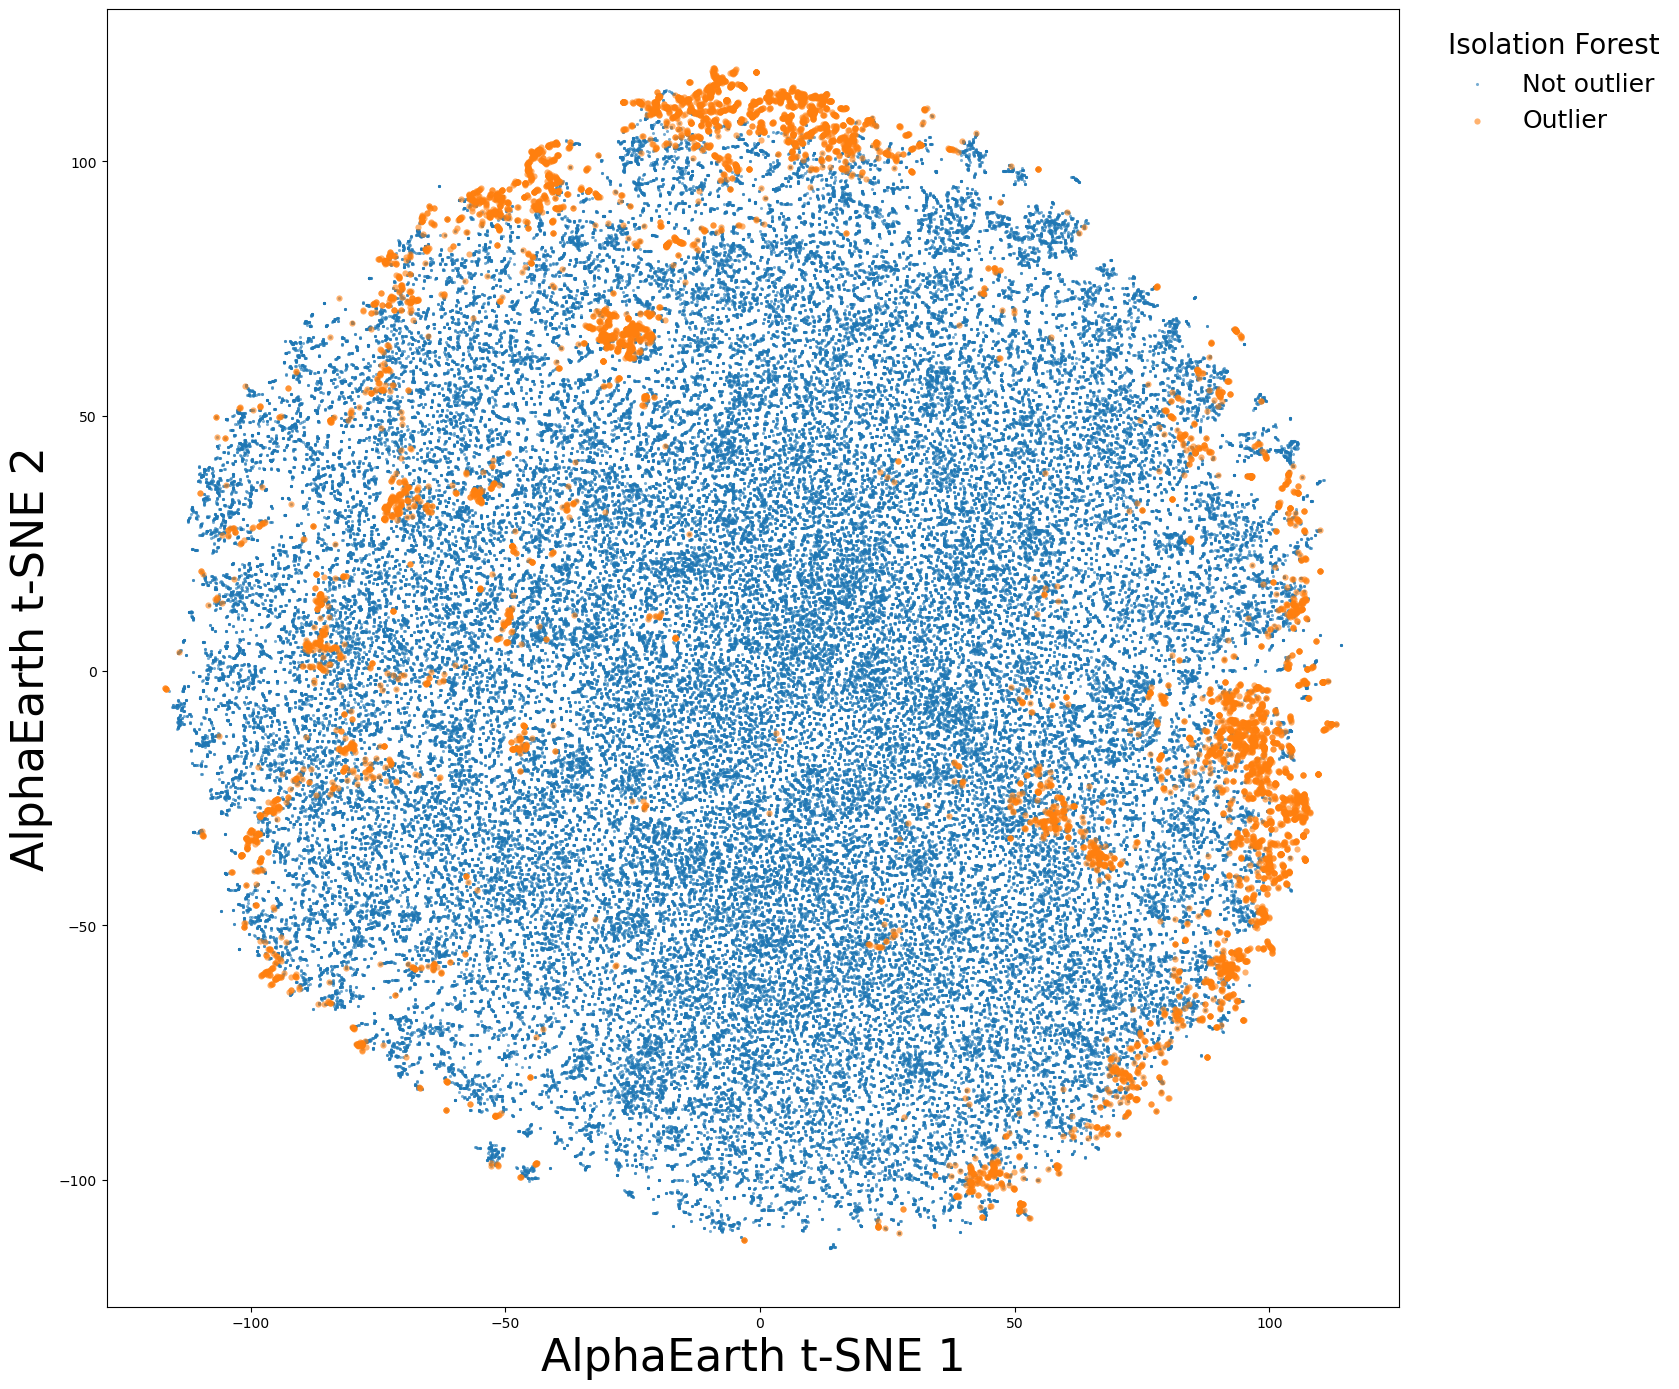


Saved Isolation Forest outlier plot:
E:\buildings\LSO\outputs\outlier_results_isolation_forest\tsne_alphaearth_by_isolation_forest_outlier_LSO_large.png

Creating Google Open Buildings 2.5D confidence plot...


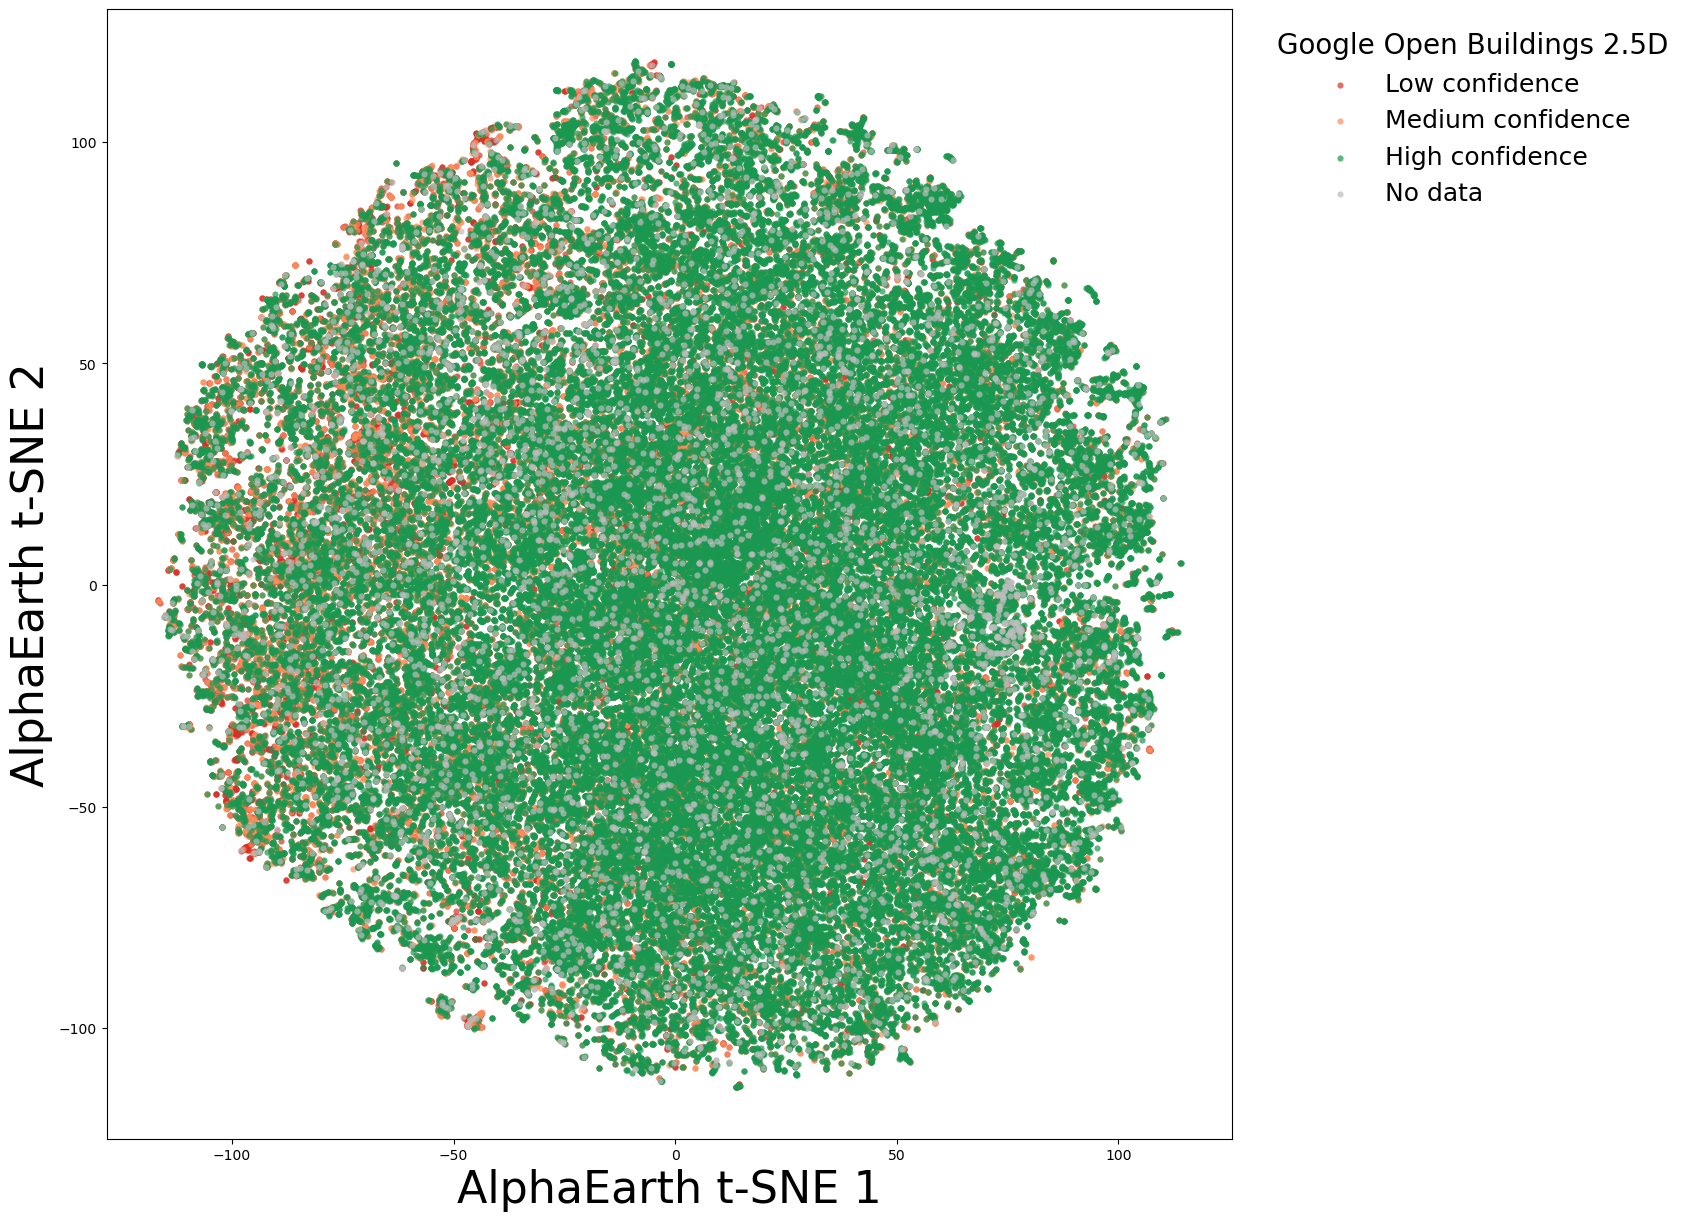


Saved Google 2.5D confidence plot:
E:\buildings\LSO\outputs\outlier_results_isolation_forest\tsne_alphaearth_by_google25d_confidence_LSO_large.png

PLOT SUMMARY

1. Dynamic World class plot:
E:\buildings\LSO\outputs\outlier_results_isolation_forest\tsne_alphaearth_by_class_LSO_large.png

2. Isolation Forest outlier plot:
E:\buildings\LSO\outputs\outlier_results_isolation_forest\tsne_alphaearth_by_isolation_forest_outlier_LSO_large.png

3. Google Open Buildings 2.5D confidence plot:
E:\buildings\LSO\outputs\outlier_results_isolation_forest\tsne_alphaearth_by_google25d_confidence_LSO_large.png

Finished.


In [ ]:
# ============================================================
# Plot t-SNE, Dynamic World, Isolation Forest Outliers,
# and Google Open Buildings 2.5D Confidence
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS - input buildings data with attached t-SNE and Isolation Forest results
# ============================================================

INPUT_FOLDER = (
    rf"E:\buildings\{city}\outputs"
    rf"\outlier_results_isolation_forest"
)

INPUT_CSV = (
    rf"{INPUT_FOLDER}"
    rf"\{city}_buildings_isolation_forest_tsne.csv"
)

OUTPUT_FOLDER = (
    rf"E:\buildings\{city}\outputs\outlier_results_isolation_forest"
)


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_CSV)

print(
    f"Loaded {len(df):,} buildings"
)


# ============================================================
# COLUMN NAMES
# ============================================================

# ------------------------------------------------------------
# Existing t-SNE dimensions
# ------------------------------------------------------------

TSNE_X = "TSNE1"
TSNE_Y = "TSNE2"


# ------------------------------------------------------------
# Dynamic World
# ------------------------------------------------------------

CLASS_COLUMN = "dw_top_class_name"


# ------------------------------------------------------------
# Existing Isolation Forest outlier field
# ------------------------------------------------------------

OUTLIER_COLUMN = "isolation_forest_outlier"


# ------------------------------------------------------------
# Google Open Buildings 2.5D
# ------------------------------------------------------------

GOOGLE_25D_COLUMN = "google25d_max_confidence"


# ============================================================
# CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [

    TSNE_X,

    TSNE_Y,

    CLASS_COLUMN,

    OUTLIER_COLUMN,

    GOOGLE_25D_COLUMN

]


missing = [

    col

    for col in required_columns

    if col not in df.columns

]


if missing:

    raise ValueError(

        f"Missing required columns: {missing}"

    )


print(
    "\nUsing columns:"
)

print(
    f"  t-SNE 1          : {TSNE_X}"
)

print(
    f"  t-SNE 2          : {TSNE_Y}"
)

print(
    f"  Dynamic World    : {CLASS_COLUMN}"
)

print(
    f"  Isolation Forest : {OUTLIER_COLUMN}"
)

print(
    f"  Google 2.5D      : {GOOGLE_25D_COLUMN}"
)


# ============================================================
# PREPARE DATA
# ============================================================

plot_df = df[
    required_columns
].copy()


# ------------------------------------------------------------
# Convert t-SNE coordinates to numeric
# ------------------------------------------------------------

plot_df[TSNE_X] = pd.to_numeric(

    plot_df[TSNE_X],

    errors="coerce"

)


plot_df[TSNE_Y] = pd.to_numeric(

    plot_df[TSNE_Y],

    errors="coerce"

)


# ------------------------------------------------------------
# Convert Google 2.5D confidence to numeric
# ------------------------------------------------------------

plot_df[GOOGLE_25D_COLUMN] = pd.to_numeric(

    plot_df[GOOGLE_25D_COLUMN],

    errors="coerce"

)


# ------------------------------------------------------------
# Remove buildings without t-SNE coordinates
# ------------------------------------------------------------

plot_df = plot_df.dropna(

    subset=[TSNE_X, TSNE_Y]

)


print(

    f"\nBuildings with valid t-SNE coordinates: "
    f"{len(plot_df):,}"

)


# ============================================================
# CONVERT ISOLATION FOREST OUTLIER TO BOOLEAN
# ============================================================

def convert_outlier(value):

    if pd.isna(value):

        return False


    if isinstance(value, bool):

        return value


    if isinstance(value, (int, float)):

        return value == 1


    return str(value).strip().lower() in [

        "true",

        "1",

        "yes"

    ]


plot_df["is_outlier"] = (

    plot_df[OUTLIER_COLUMN]

    .apply(convert_outlier)

)


# ============================================================
# ISOLATION FOREST OUTLIER SUMMARY
# ============================================================

outlier_count = (

    plot_df["is_outlier"]

    .sum()

)


non_outlier_count = (

    (~plot_df["is_outlier"])

    .sum()

)


outlier_percent = (

    outlier_count

    / len(plot_df)

    * 100

)


non_outlier_percent = (

    non_outlier_count

    / len(plot_df)

    * 100

)


print(
    "\n" + "=" * 60
)

print(
    "ISOLATION FOREST OUTLIER SUMMARY"
)

print(
    "=" * 60
)

print(
    f"Not outlier : "
    f"{non_outlier_count:,} "
    f"({non_outlier_percent:.2f}%)"
)

print(
    f"Outlier     : "
    f"{outlier_count:,} "
    f"({outlier_percent:.2f}%)"
)

print(
    "=" * 60
)


# ============================================================
# DYNAMIC WORLD CLASS COLORS
# ============================================================

CLASS_COLORS = {

    "Bare": "#E67E00",

    "Built": "#E91E63",

    "Crops": "#FFD600",

    "Flooded vegetation": "#00B8B8",

    "Grass": "#64DD17",

    "Shrubs & scrub": "#7B1FA2",

    "Trees": "#087F3E",

    "Water": "#1565E8"

}


# ============================================================
# DYNAMIC WORLD CLASS ORDER
# ============================================================

class_order = [

    "Bare",

    "Built",

    "Crops",

    "Flooded vegetation",

    "Grass",

    "Shrubs & scrub",

    "Trees",

    "Water"

]


# ============================================================
# GOOGLE 2.5D CONFIDENCE CLASSIFICATION
# ============================================================

def classify_google_confidence(value):

    # No value
    if pd.isna(value):

        return "No data"


    # Low confidence
    if value < 0.1:

        return "Low confidence"


    # Medium confidence
    elif value < 0.5:

        return "Medium confidence"


    # High confidence
    else:

        return "High confidence"


plot_df["google_25d_confidence"] = (

    plot_df[GOOGLE_25D_COLUMN]

    .apply(classify_google_confidence)

)


# ============================================================
# GOOGLE 2.5D CONFIDENCE COLORS
# ============================================================

CONFIDENCE_COLORS = {

    "Low confidence": "#D73027",

    "Medium confidence": "#FC8D59",

    "High confidence": "#1A9850",

    "No data": "#BDBDBD"

}


# ============================================================
# GOOGLE 2.5D CONFIDENCE ORDER
# ============================================================

confidence_order = [

    "Low confidence",

    "Medium confidence",

    "High confidence",

    "No data"

]


# ============================================================
# GOOGLE 2.5D CONFIDENCE SUMMARY
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "GOOGLE OPEN BUILDINGS 2.5D CONFIDENCE"
)

print(
    "=" * 60
)


confidence_counts = (

    plot_df["google_25d_confidence"]

    .value_counts()

    .reindex(

        confidence_order,

        fill_value=0

    )

)


confidence_percent = (

    confidence_counts

    / len(plot_df)

    * 100

)


for category in confidence_order:

    count = confidence_counts[category]

    percent = confidence_percent[category]

    print(

        f"{category:<20} "

        f"{count:>10,} "

        f"({percent:6.2f}%)"

    )


print(
    "=" * 60
)


# ============================================================
# PLOT 1
# t-SNE COLORED BY DYNAMIC WORLD TOP CLASS
# ============================================================

print(
    "\nCreating Dynamic World class plot..."
)


fig, ax = plt.subplots(

    figsize=(18, 14)

)


# ------------------------------------------------------------
# Plot each Dynamic World class
# ------------------------------------------------------------

for class_name in class_order:

    subset = plot_df[

        plot_df[CLASS_COLUMN]

        == class_name

    ]


    if len(subset) > 0:

        ax.scatter(

            subset[TSNE_X],

            subset[TSNE_Y],

            s=20,

            alpha=0.7,

            linewidths=0,

            color=CLASS_COLORS[class_name],

            label=class_name

        )


    else:

        # Empty point so class still appears in legend
        ax.scatter(

            [],

            [],

            s=5,

            alpha=0.7,

            linewidths=0,

            color=CLASS_COLORS[class_name],

            label=class_name

        )


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(

    "AlphaEarth t-SNE 1",

    fontsize=32

)


ax.set_ylabel(

    "AlphaEarth t-SNE 2",

    fontsize=32

)


ax.set_title("")


ax.set_aspect(

    "equal",

    adjustable="box"

)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

# Uncomment if you want the legend displayed

# ax.legend(
#
#     title="Dynamic World Top Class",
#
#     bbox_to_anchor=(1.02, 1),
#
#     loc="upper left",
#
#     frameon=False,
#
#     fontsize=18,
#
#     title_fontsize=20
#
# )


# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout(

    rect=[0, 0, 0.80, 1]

)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT_CLASS = os.path.join(

    OUTPUT_FOLDER,

    f"tsne_alphaearth_by_class_{city}_large.png"

)


plt.savefig(

    OUTPUT_CLASS,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(
    "\nSaved class plot:"
)

print(
    OUTPUT_CLASS
)


# ============================================================
# PLOT 2
# t-SNE COLORED BY ISOLATION FOREST OUTLIER
# ============================================================

print(
    "\nCreating Isolation Forest outlier plot..."
)


fig, ax = plt.subplots(

    figsize=(18, 14)

)


# ------------------------------------------------------------
# Normal buildings
# ------------------------------------------------------------

normal = plot_df[

    plot_df["is_outlier"] == False

]


# ------------------------------------------------------------
# Outliers
# ------------------------------------------------------------

outliers = plot_df[

    plot_df["is_outlier"] == True

]


print(
    f"  Not outlier: {len(normal):,}"
)

print(
    f"  Outlier    : {len(outliers):,}"
)


# ------------------------------------------------------------
# Plot normal buildings first
# ------------------------------------------------------------

ax.scatter(

    normal[TSNE_X],

    normal[TSNE_Y],

    s=5,

    alpha=0.6,

    linewidths=0,

    label="Not outlier"

)


# ------------------------------------------------------------
# Plot outliers on top
# ------------------------------------------------------------

ax.scatter(

    outliers[TSNE_X],

    outliers[TSNE_Y],

    s=20,

    alpha=0.6,

    linewidths=0,

    label="Outlier"

)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(

    "AlphaEarth t-SNE 1",

    fontsize=32

)


ax.set_ylabel(

    "AlphaEarth t-SNE 2",

    fontsize=32

)


ax.set_title("")


ax.set_aspect(

    "equal",

    adjustable="box"

)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(

    title="Isolation Forest",

    bbox_to_anchor=(1.02, 1),

    loc="upper left",

    frameon=False,

    fontsize=18,

    title_fontsize=20

)


# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout(

    rect=[0, 0, 0.80, 1]

)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT_OUTLIER = os.path.join(

    OUTPUT_FOLDER,

    f"tsne_alphaearth_by_isolation_forest_outlier_{city}_large.png"

)


plt.savefig(

    OUTPUT_OUTLIER,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(
    "\nSaved Isolation Forest outlier plot:"
)

print(
    OUTPUT_OUTLIER
)


# ============================================================
# PLOT 3
# t-SNE COLORED BY GOOGLE OPEN BUILDINGS 2.5D CONFIDENCE
# ============================================================

print(
    "\nCreating Google Open Buildings 2.5D confidence plot..."
)


fig, ax = plt.subplots(

    figsize=(18, 14)

)


# ============================================================
# PLOT CONFIDENCE CATEGORIES
# ============================================================

for confidence_class in confidence_order:

    subset = plot_df[

        plot_df["google_25d_confidence"]

        == confidence_class

    ]


    if len(subset) == 0:

        continue


    ax.scatter(

        subset[TSNE_X],

        subset[TSNE_Y],

        s=20,

        alpha=0.7,

        linewidths=0,

        color=CONFIDENCE_COLORS[

            confidence_class

        ],

        label=confidence_class

    )


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xlabel(

    "AlphaEarth t-SNE 1",

    fontsize=32

)


ax.set_ylabel(

    "AlphaEarth t-SNE 2",

    fontsize=32

)


ax.set_title("")


ax.set_aspect(

    "equal",

    adjustable="box"

)


# ============================================================
# LEGEND
# ============================================================

ax.legend(

    title="Google Open Buildings 2.5D",

    bbox_to_anchor=(1.02, 1),

    loc="upper left",

    frameon=False,

    fontsize=18,

    title_fontsize=20

)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(

    rect=[0, 0, 0.80, 1]

)


# ============================================================
# SAVE
# ============================================================

OUTPUT_GOOGLE_25D = os.path.join(

    OUTPUT_FOLDER,

    f"tsne_alphaearth_by_google25d_confidence_{city}_large.png"

)


plt.savefig(

    OUTPUT_GOOGLE_25D,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(
    "\nSaved Google 2.5D confidence plot:"
)

print(
    OUTPUT_GOOGLE_25D
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "PLOT SUMMARY"
)

print(
    "=" * 60
)


print(
    "\n1. Dynamic World class plot:"
)

print(
    OUTPUT_CLASS
)


print(
    "\n2. Isolation Forest outlier plot:"
)

print(
    OUTPUT_OUTLIER
)


print(
    "\n3. Google Open Buildings 2.5D confidence plot:"
)

print(
    OUTPUT_GOOGLE_25D
)


print(
    "\n" + "=" * 60
)

print(
    "Finished."
)

print(
    "=" * 60
)


